<a href="https://colab.research.google.com/github/RishithN/AI-Ration/blob/main/NLP_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import tarfile
import pandas as pd
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
tar = tarfile.open("review_polarity.tar.gz")
tar.extractall()
tar.close()

/tmp/ipykernel_293/1094018573.py:2: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


In [ ]:
data = []
labels = []

pos_path = "txt_sentoken/pos"
neg_path = "txt_sentoken/neg"

for file in os.listdir(pos_path):
    with open(os.path.join(pos_path, file), encoding="utf8") as f:
        data.append(f.read())
        labels.append("positive")

for file in os.listdir(neg_path):
    with open(os.path.join(neg_path, file), encoding="utf8") as f:
        data.append(f.read())
        labels.append("negative")

df = pd.DataFrame({
    "review": data,
    "sentiment": labels
})

print(df.head())

                                              review sentiment
0  disaster films have a tendency to be very form...  positive
1  today , war became a reality to me after seein...  positive
2  ingredients : london gal , fate , true love , ...  positive
3  let's face it : the $100 million-plus smash th...  positive
4  a standoff . \na man holds a woman , a diploma...  positive


In [ ]:
import re
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df["clean_review"] = df["review"].apply(preprocess)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["clean_review"])
y = df["sentiment"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.81

Classification Report:

              precision    recall  f1-score   support

    negative       0.79      0.84      0.82       201
    positive       0.83      0.78      0.80       199

    accuracy                           0.81       400
   macro avg       0.81      0.81      0.81       400
weighted avg       0.81      0.81      0.81       400


Confusion Matrix:

[[169  32]
 [ 44 155]]


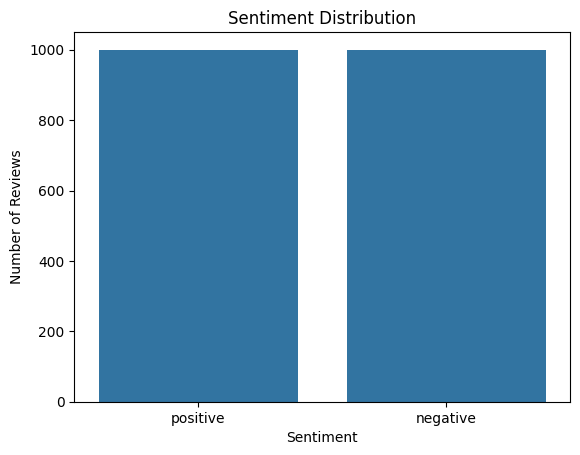

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

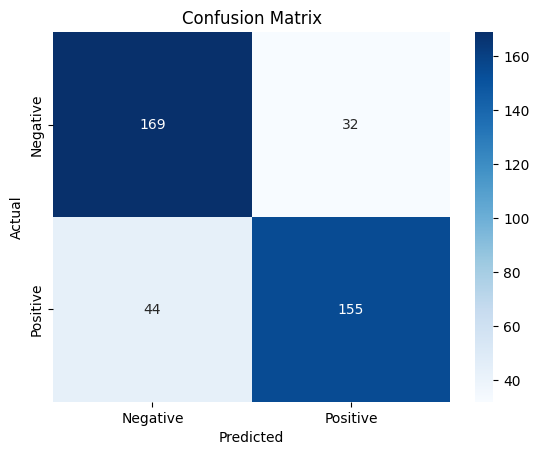

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

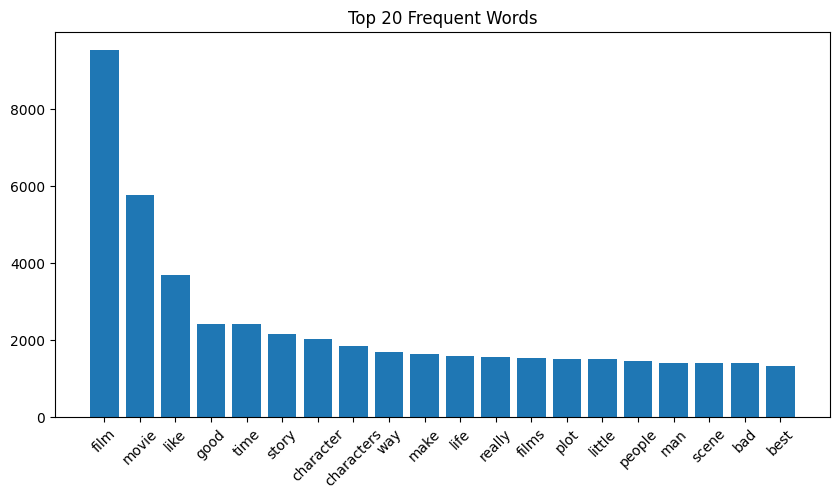

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words='english')
X_words = vectorizer.fit_transform(df['clean_review'])

sum_words = X_words.sum(axis=0)

words_freq = [(word, sum_words[0, idx])
              for word, idx in vectorizer.vocabulary_.items()]

words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:20]

words = [w[0] for w in words_freq]
counts = [w[1] for w in words_freq]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Frequent Words")
plt.show()

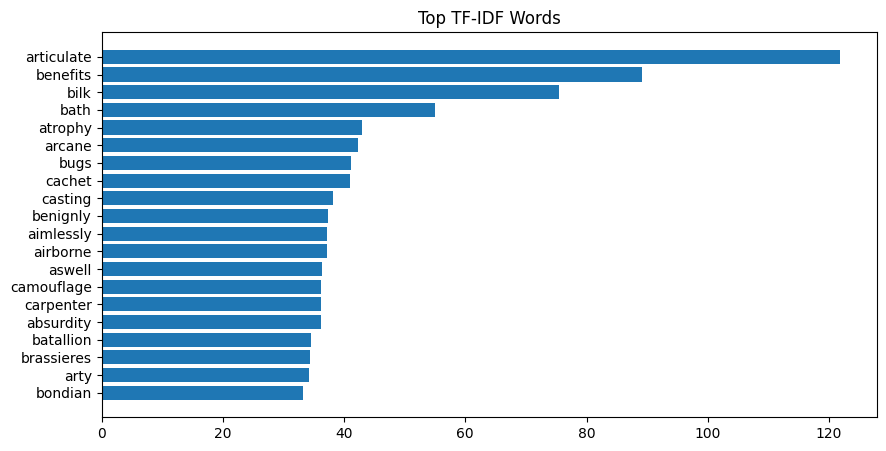

In [ ]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()
tfidf_scores = X.toarray().sum(axis=0)

top_indices = np.argsort(tfidf_scores)[-20:]

top_words = [feature_names[i] for i in top_indices]
scores = tfidf_scores[top_indices]

plt.figure(figsize=(10,5))
plt.barh(top_words, scores)
plt.title("Top TF-IDF Words")
plt.show()